# **INTRODUCCIÓN A SEÑALES BIOMÉDICAS**

## Adquisición de datos: ***PTB Diagnostic ECG Database:***

Esta base de datos presenta 549 grabaciones de 290 pacientes diferentes los cuáles fueron tomados 15 derivaciones (i,ii,iii,avr, avl, avf, v1, v2, v3, v4, v5, v6,vx, vy, vz) muestreadas a 1KHz, cada uno fue separado por edad y sexo además, de presentar alguna patología la cuál es mostrada por el siguiente recuadro:

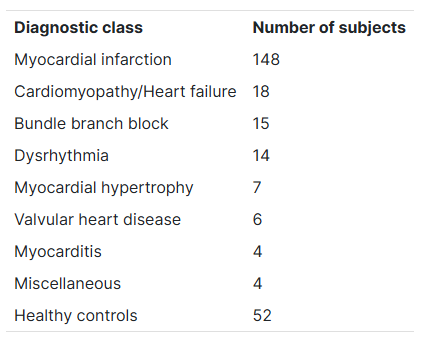

In [ ]:
#Descargamos el zip:
!wget https://physionet.org/static/published-projects/ptbdb/ptb-diagnostic-ecg-database-1.0.0.zip
#Se descomprime:
!unzip -q ptb-diagnostic-ecg-database-1.0.0.zip

--2026-06-08 01:48:27--  https://physionet.org/static/published-projects/ptbdb/ptb-diagnostic-ecg-database-1.0.0.zip
Resolving physionet.org (physionet.org)... 18.13.52.205
Connecting to physionet.org (physionet.org)|18.13.52.205|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://physionet.org/content/ptbdb/get-zip/1.0.0/ [following]
--2026-06-08 01:48:28--  https://physionet.org/content/ptbdb/get-zip/1.0.0/
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 1790456359 (1.7G) [application/zip]
Saving to: ‘ptb-diagnostic-ecg-database-1.0.0.zip’

ptb-diagnostic-ecg- 100%[===================>]   1.67G   261KB/s    in 1h 46m  

2026-06-08 03:34:40 (274 KB/s) - ‘ptb-diagnostic-ecg-database-1.0.0.zip’ saved [1790456359/1790456359]



##Separación de datos: ***ECG sano vs ECG patológico***:

Gracias a los archivos md en la base **(CONTROLS y RECORDS)** se pueden separar las mediciones en dos grandes grupos, inicialmente deseamos realizar la división entre ECG sano e infarto de miocardio y trabajar a partir del segundo, sin embargo por cuestiones de tiempo nos enfocaremos en determinar ECG sano y patológico


In [ ]:
import os
from google.colab import drive
#Conectamos al drive:
drive.mount('/content/drive')
#La carpeta descomprimida
ruta_base = '/content/ptb-diagnostic-ecg-database-1.0.0/'
ruta_controls = os.path.join(ruta_base, 'CONTROLS')
pacientes_sanos = set()
#Extraemos el ID de los controles (pacientes sanos)
with open(ruta_controls, 'r') as f:
    for line in f:
        if line.strip():
            paciente = line.split('/')[0]
            pacientes_sanos.add(paciente)
ruta_records = os.path.join(ruta_base, 'RECORDS')
pacientes_todos = set()
#Extraemos el ID de los records (pacientes totales)
with open(ruta_records, 'r') as f:
    for line in f:
        if line.strip():
            paciente = line.split('/')[0]
            pacientes_todos.add(paciente)
#Hallamos los pacientes patológicos
pacientes_patologicos = pacientes_todos - pacientes_sanos
#Imprimimos para verificarlo con la tabla de la base de datos:
print(f"Total Sanos: {len(pacientes_sanos)}")
print(f"Total Patológicos: {len(pacientes_patologicos)}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total Sanos: 52
Total Patológicos: 238


##Extracción de derivaciones ***I,II y III:***

Se extraerán las tres derivaciones con el ID del paciente y se guardarán en un diccionario en formato pickle, con esto ya no tendremos que descargar la base de datos cada vez que quisieramos usarla, sino estará en el drive en todo momento

In [ ]:
import os
import wfdb
import numpy as np
import pickle
ruta_drive = '/content/drive/MyDrive/INTRODUCCION_A_SEÑALES/PROYECTO_SEÑALES/Datos_Clasificados'
os.makedirs(ruta_drive, exist_ok=True)
ruta_base = '/content/ptb-diagnostic-ecg-database-1.0.0/'
def extraer_por_paciente(lista_pacientes, ruta_origen, nombre_archivo_salida):
    datos_pacientes = {}
    derivaciones_deseadas = ['i', 'ii', 'iii']
    #De ahi lo borro, es para ver que esta funcionando
    print(f"Extracción en: {nombre_archivo_salida}")
    for paciente in lista_pacientes:
        ruta_paciente = os.path.join(ruta_origen, paciente)
        matrices_del_paciente = []
        if not os.path.exists(ruta_paciente):
            continue
        archivos_registro = [f.replace('.hea', '') for f in os.listdir(ruta_paciente) if f.endswith('.hea')]
        for archivo in archivos_registro:
            ruta_completa = os.path.join(ruta_paciente, archivo)
            try:
                senal_completa, metadatos = wfdb.rdsamp(ruta_completa)
                nombres_canales = metadatos['sig_name']
                indices = [nombres_canales.index(der) for der in derivaciones_deseadas if der in nombres_canales]
                if len(indices) == 3:
                    senal_filtrada = senal_completa[:, indices]
                    #Si estan las tres derivaciones las agregamos a la lista
                    matrices_del_paciente.append(senal_filtrada)
            except Exception as e:
                pass
        #Guardamos el registro con el ID del paciente
        if matrices_del_paciente:
            datos_pacientes[paciente] = matrices_del_paciente
    #Guardamos en el drive
    ruta_guardado = os.path.join(ruta_drive, nombre_archivo_salida)
    with open(ruta_guardado, 'wb') as f:
        pickle.dump(datos_pacientes, f)
    #Luego borro esto es solo para ver
    print(f"Guardado en: {ruta_guardado}")
    return datos_pacientes
#Ejecutamos
sanos_data = extraer_por_paciente(pacientes_sanos, ruta_base, 'sanos_derivaciones_por_paciente.pkl')
patologicos_data = extraer_por_paciente(pacientes_patologicos, ruta_base, 'patologicos_derivaciones_por_paciente.pkl')

Extracción en: sanos_derivaciones_por_paciente.pkl
Guardado en: /content/drive/MyDrive/INTRODUCCION_A_SEÑALES/PROYECTO_SEÑALES/Datos_Clasificados/sanos_derivaciones_por_paciente.pkl
Extracción en: patologicos_derivaciones_por_paciente.pkl
Guardado en: /content/drive/MyDrive/INTRODUCCION_A_SEÑALES/PROYECTO_SEÑALES/Datos_Clasificados/patologicos_derivaciones_por_paciente.pkl


##Acondicionamiento de la señal: ***Filtros y Actualización de data***

Se utilizarán filtros para disminuir el ruido lo mayor posible de los archivos crudos (.dat) para posteriormente poder clasificarlos:

###**Filtro Notch (50Hz):**
Para eliminar la interferencia eléctrica, el 50Hz se debe a que la toma de datos se realizó en Alemania y la frecuencia de la unión europea es esta

###**Filtro ButterWorth Pasa Banda (0.5Hz 40Hz):**
El primer corte sirve para eliminar la deriva de linea base que se genera por la respiración o el mal contacto físico de los electrodos y el segundo corte sirve para eliminar el ruido muscular

###**Uso de filtfilt:**
Utilizaremos Zero-phase filtering ya que los comunes generan un pequeño retraso, lo cuál podría deformar la duración del complejo QRS o el intervalo PR, filtfilt filtra en una dirección y luego en reversa cancelando este desfase

In [ ]:
import os
import pickle
import numpy as np
from scipy.signal import butter, iirnotch, filtfilt
ruta_drive = '/content/drive/MyDrive/INTRODUCCION_A_SEÑALES/PROYECTO_SEÑALES/Datos_Clasificados'
fs = 1000.0  # Frecuencia que se menciona en la base de datos
def aplicar_filtros(senal_matriz):
    f0 = 50.0
    Q = 30.0
    #Filtro Notch:
    b_notch, a_notch = iirnotch(f0, Q, fs)
    #Filtro Pasabanda:
    b_band, a_band = butter(4, [0.5, 40.0], btype='bandpass', fs=fs)
    senal_limpia = np.zeros_like(senal_matriz)
    #Como nuestras derivaciones estan separadas por columnas,iteramos en cada una:
    for columna in range(senal_matriz.shape[1]):
        canal_crudo = senal_matriz[:, columna]
        #Usamos el filtfilt
        y_notch = filtfilt(b_notch, a_notch, canal_crudo)
        y_final = filtfilt(b_band, a_band, y_notch)
        senal_limpia[:, columna] = y_final
    return senal_limpia
def procesar_diccionario_pacientes(nombre_archivo_entrada, nombre_archivo_salida):
    ruta_entrada = os.path.join(ruta_drive, nombre_archivo_entrada)
    ruta_salida = os.path.join(ruta_drive, nombre_archivo_salida)
    #Para ver :b
    print(f"Cargando {nombre_archivo_entrada} para filtrado")
    with open(ruta_entrada, 'rb') as f:
        datos_crudos = pickle.load(f)
    datos_limpios = {}
    for paciente, lista_matrices in datos_crudos.items():
        matrices_limpias_del_paciente = []
        #Filtramos todos:
        for matriz in lista_matrices:
            matriz_filtrada = aplicar_filtros(matriz)
            matrices_limpias_del_paciente.append(matriz_filtrada)
        datos_limpios[paciente] = matrices_limpias_del_paciente
    #Guardamos el nuevo diccionario con las señales limpias:
    with open(ruta_salida, 'wb') as f:
        pickle.dump(datos_limpios, f)
    #Luego lo borro, lo veo después
    print(f"Filtrado completo,guardado en: {ruta_salida}\n")
    return datos_limpios
#Reemplazamos el diccionario por el nuevo con la señal limpia:
sanos_limpios = procesar_diccionario_pacientes('sanos_derivaciones_por_paciente.pkl', 'sanos_limpios.pkl')
patologicos_limpios = procesar_diccionario_pacientes('patologicos_derivaciones_por_paciente.pkl', 'patologicos_limpios.pkl')

Cargando sanos_derivaciones_por_paciente.pkl para filtrado
Filtrado completo,guardado en: /content/drive/MyDrive/INTRODUCCION_A_SEÑALES/PROYECTO_SEÑALES/Datos_Clasificados/sanos_limpios.pkl

Cargando patologicos_derivaciones_por_paciente.pkl para filtrado
Filtrado completo,guardado en: /content/drive/MyDrive/INTRODUCCION_A_SEÑALES/PROYECTO_SEÑALES/Datos_Clasificados/patologicos_limpios.pkl



Se generaron los siguientes archivos:


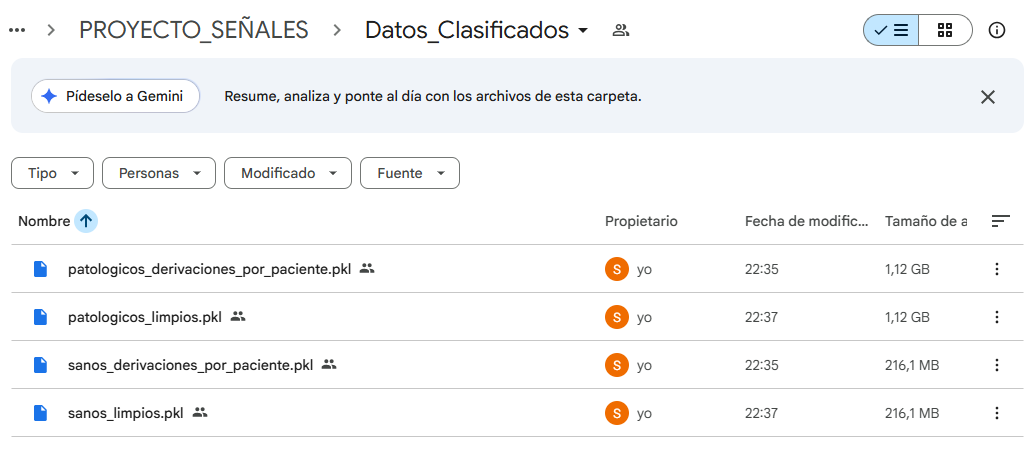

###Ploteamos para ver el efecto del acondicionamiento: ***(Filtro Notch + Pasabanda + Filtfilt)***

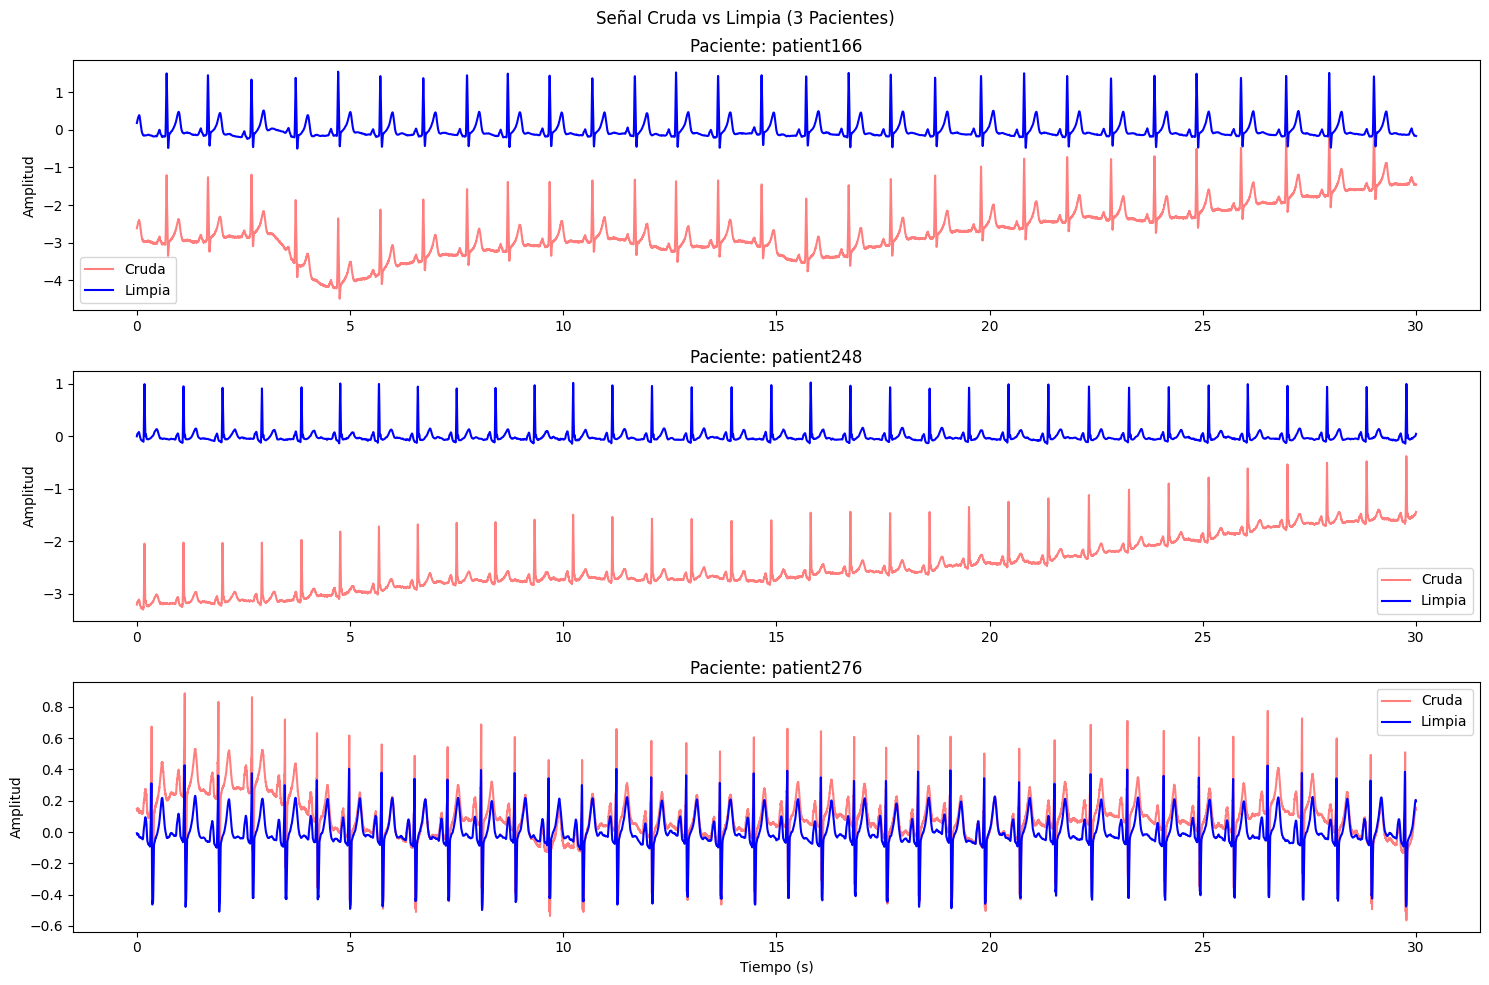

In [ ]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
ruta_drive = '/content/drive/MyDrive/INTRODUCCION_A_SEÑALES/PROYECTO_SEÑALES/Datos_Clasificados'
#Carga de los datos:
with open(os.path.join(ruta_drive,'sanos_derivaciones_por_paciente.pkl'), 'rb') as f:
    sanos_crudos = pickle.load(f)
with open(os.path.join(ruta_drive, 'sanos_limpios.pkl'), 'rb') as f:
    sanos_limpios = pickle.load(f)
#Extraemos los 3 primeros pacientes en lugar de solo 1
pacientes_3 = list(sanos_crudos.keys())[0:3]
#Parametros
fs = 1000
N = 30000  #Plotearemos los 30 primeros segundos (1000 samplesxseg)
t = np.arange(N) / fs
#Graficamos
plt.figure(figsize=(15, 10))
plt.suptitle('Señal Cruda vs Limpia (3 Pacientes)')
#Bucle para plotear
for i in range(3):
    paciente_actual = pacientes_3[i]
    senal_cruda = sanos_crudos[paciente_actual][0][:, 1]
    senal_limpia = sanos_limpios[paciente_actual][0][:, 1]
    plt.subplot(3, 1, i+1) # Separa en 3 filas
    plt.plot(t, senal_cruda[:N], label='Cruda', color='red', alpha=0.5)
    plt.plot(t, senal_limpia[:N], label='Limpia', color='blue')
    plt.title(f'Paciente: {paciente_actual}')
    plt.ylabel('Amplitud')
    plt.legend()
plt.xlabel('Tiempo (s)')
plt.tight_layout()
plt.show()

###Detección de picos R: ***Usamos neurokit2***

Con nk_ecg_peaks nos vamos a ahorrar la determinación de los picos R, este comando del neurokit es una versión optimizada del algoritmo Pan-Tompkins. No vamos a usar las tres derivaciones, solo la II ya que es la mejor para determinar estos y tiene el pico R más pronunciado

In [ ]:
!pip install neurokit2
import os
import pickle
import numpy as np
import neurokit2 as nk
ruta_drive = '/content/drive/MyDrive/INTRODUCCION_A_SEÑALES/PROYECTO_SEÑALES/Datos_Clasificados'
def detectar_picos_r(nombre_archivo_entrada, nombre_archivo_salida):
    ruta_entrada = os.path.join(ruta_drive, nombre_archivo_entrada)
    ruta_salida = os.path.join(ruta_drive, nombre_archivo_salida)
    #Para ver que funciona después lo borro:
    print(f"Abriendo {nombre_archivo_entrada}")
    with open(ruta_entrada, 'rb') as f:
        datos_limpios = pickle.load(f)
    datos_picos = {}
    for paciente, lista_matrices in datos_limpios.items():
        picos_del_paciente = []
        for matriz in lista_matrices:
            #Extraemos solo la derivación 2
            derivacion_ii = matriz[:, 1]
            try:
                #Usamos la función de neurokit para sacar los picos
                _,info_picos = nk.ecg_peaks(derivacion_ii, sampling_rate=1000)
                # Extraemos el arreglo con las posiciones exactas de los picos
                ubicacion_picos = info_picos["ECG_R_Peaks"]
                picos_del_paciente.append(ubicacion_picos)
            except Exception as e:
                # Si algún registro está dañado, lo ignoramos para no tumbar el código
                pass
        # Guardamos la lista de picos bajo el ID del paciente
        if picos_del_paciente:
            datos_picos[paciente] = picos_del_paciente
    with open(ruta_salida, 'wb') as f:
        pickle.dump(datos_picos, f)
    print(f"Picos guardados en: {ruta_salida}\n")
    return datos_picos
# Ejecutamos la detección masiva para sanos y patológicos
sanos_picos = detectar_picos_r('sanos_limpios.pkl', 'sanos_picos_ii.pkl')
patologicos_picos = detectar_picos_r('patologicos_limpios.pkl', 'patologicos_picos_ii.pkl')


Abriendo sanos_limpios.pkl
Picos guardados en: /content/drive/MyDrive/INTRODUCCION_A_SEÑALES/PROYECTO_SEÑALES/Datos_Clasificados/sanos_picos_ii.pkl

Abriendo patologicos_limpios.pkl
Picos guardados en: /content/drive/MyDrive/INTRODUCCION_A_SEÑALES/PROYECTO_SEÑALES/Datos_Clasificados/patologicos_picos_ii.pkl



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##Cálculo de características temporales ***(Frecuencia cardiaca , HRV)*** y estadísticas ***(media, RMS, varianza)***:

###***Características temporales:***

*   **Frecuencia cardíaca (HR):** Promedio de latidos por minuto (cantidad de picos R). Sirve para determinar taquicardias (por encima del normal) o bradicardias (por debajo del normal)
*   **Variabilidad de la frecuencia cardíaca:** Es la desviación estándar del R-R, que tan constante es en el tiempo. Un alto HRV: corazón sano. Por otro lado un HRV bajo indica un corazón rígido, el cuál es un predictor de insuficiencia cardíaca, estrés agudo o neuropatía diabética

###***Características estadísticas:***

* **Valor RMS:** Potencia efectiva de la señal eléctrica. Importante para determinar infartos de miocardio, cuando se sufre esto, una parte del músculo cardiaco muere, por lo tanto no puede conducir electricidad, haciendo que el valor RMS caiga drásticamente
*   **Varianza:** Que tan dispersos están del centro, miden que tan picuda sería la señal. Esto nos serviría para casos de hipertrofia ventricular donde los picos R son altísimos disparando la varianza o para casos de bloqueo de rama donde la señal QRS se ensancha y deforma, lo cuál también afecta este valor
*  **Media:** Promedio de voltaje. Podría relacionarse a un infarto agudo (cuando el segmento ST se eleva demasiado) la media se ve desplazada





In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
ruta_drive = '/content/drive/MyDrive/INTRODUCCION_A_SEÑALES/PROYECTO_SEÑALES/Datos_Clasificados'
def extraer_datos_simples(archivo_senales, archivo_picos, etiqueta):
    #Abrimos los archivos:
    with open(os.path.join(ruta_drive, archivo_senales), 'rb') as f:
        senales = pickle.load(f)
    with open(os.path.join(ruta_drive, archivo_picos), 'rb') as f:
        picos = pickle.load(f)
    lista_datos = []
    for paciente in senales.keys():
        #En algunos pacientes se tomaron muestras control varias veces, solo escogemos una por paciente
        #ya que sino al momento de entrenar,cada paciente tendría un peso diferente y sería más dificil:
        matriz = senales[paciente][0]
        picos_r = picos[paciente][0]
        #Hallamos la freq cardiaca:
        rr_intervalos = np.diff(picos_r) / 1000.0
        frec_cardiaca = 60.0 / np.mean(rr_intervalos) if len(rr_intervalos) > 0 else 0
        fila = {
            'ID_Paciente': paciente,
            'Frec_Cardiaca': frec_cardiaca,
            #Valor RMS:
            'RMS_I': np.sqrt(np.mean(matriz[:, 0]**2)),
            'RMS_II': np.sqrt(np.mean(matriz[:, 1]**2)),
            'RMS_III': np.sqrt(np.mean(matriz[:, 2]**2)),
            # Varianza:
            'Var_I': np.var(matriz[:, 0]),
            'Var_II': np.var(matriz[:, 1]),
            'Var_III': np.var(matriz[:, 2]),
            'Etiqueta': etiqueta # 0 = Sano,1 = Patológico
        }
        lista_datos.append(fila)
    return lista_datos
#Ejecutamos la extracción:
datos_sanos = extraer_datos_simples('sanos_limpios.pkl', 'sanos_picos_ii.pkl',etiqueta=0)
datos_patologicos = extraer_datos_simples('patologicos_limpios.pkl', 'patologicos_picos_ii.pkl',etiqueta=1)
#Juntamos todo y creamos el Excel final:
df_final = pd.DataFrame(datos_sanos+datos_patologicos)
ruta_csv = os.path.join(ruta_drive, 'Dataset_ECG.csv')
df_final.to_csv(ruta_csv,index=False)
print(f"Dataset creado,tenemos {len(df_final)} pacientes")
df_final.head() #Para ver si funciona

Dataset creado,tenemos 290 pacientes


,ID_Paciente,Frec_Cardiaca,RMS_I,RMS_II,RMS_III,Var_I,Var_II,Var_III,Etiqueta
0,patient166,60.038973,0.228254,0.261925,0.077501,0.052100,0.068605,0.006006,0
1,patient248,62.827225,0.139889,0.135829,0.033800,0.019569,0.018449,0.001142,0
2,patient276,76.325656,0.133655,0.120670,0.169599,0.017864,0.014561,0.028764,0
3,patient150,67.124066,0.173625,0.291364,0.147337,0.030146,0.084893,0.021708,0
4,patient214,98.131311,0.116600,0.152698,0.113565,0.013596,0.023317,0.012897,0


##Entrenamiento del dataset: ***(SVM,Random Forest,Regresión Logística)***

Vamo a dividir la data en un porcentaje 80:20 (train:test) para que los modelos puedan entrenarse y poder ver cuál es el más óptimo para nuestro proyecto (el que presente mayor exactitud)

In [ ]:
import os
import pandas as pd
import numpy as np
#Para dividir nuestra data:
from sklearn.model_selection import train_test_split
#Para normalizar nuestra data:
from sklearn.preprocessing import StandardScaler
#Random forest:
from sklearn.ensemble import RandomForestClassifier
#SVM:
from sklearn.svm import SVC
#Regresión logística:
from sklearn.linear_model import LogisticRegression
#Métricas de los modelos:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
#Jalamos el dataset creado antes:
ruta_drive = '/content/drive/MyDrive/INTRODUCCION_A_SEÑALES/PROYECTO_SEÑALES/Datos_Clasificados'
ruta_csv = os.path.join(ruta_drive, 'Dataset_ECG.csv')
print("Cargando data")
#Lo convierto a dataframe para que sea más fácil manipularlo
df = pd.read_csv(ruta_csv)
#Separación de características (X) y la variable que queremos predecir (y)
#Sacamos el ID y la etiqueta (ahí dice si es sano o enfermo, por eso lo quitamos para entrenar)
X = df.drop(columns=['ID_Paciente', 'Etiqueta'])
y = df['Etiqueta']
#División del dataset(80% entrenamiento, 20% prueba)
#'stratify=y' asegura que la proporción de sanos y patológicos se mantenga idéntica en ambos sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=1, stratify=y
)
#Normalizamos:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
#Definición de los clasificadores a evaluar:
modelos = {
    "Regresión Logística": LogisticRegression(max_iter=1000, random_state=1),
    "Support Vector Machine (SVM)": SVC(kernel='rbf', probability=True, random_state=1),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=1)
}
#Ciclo de entrenamiento y evaluación comparativa
print("Modelos de Machine Learning \n")

for nombre, modelo in modelos.items():
    #Entrenando:
    modelo.fit(X_train_scaled, y_train)
    #Preedicción:
    predicciones = modelo.predict(X_test_scaled)
    #Cálculo de la exactitud
    exactitud = accuracy_score(y_test,predicciones)

    print(f"Clasificador: {nombre}")
    print(f"Exactitud (Accuracy)): {exactitud * 100:.2f}%")
    print("\nDesglose de Métricas Clínicas:")
    #Reporte(Precisión, Sensibilidad/Recall, F1-Score)
    print(classification_report(y_test, predicciones, target_names=['Sano (0)', 'Patológico (1)']))
    #Matriz de Confusión
    matriz = confusion_matrix(y_test, predicciones)
    print("Matriz de Confusión:")
    print(f"   [Verdaderos Sanos: {matriz[0,0]}   Falsos Patológicos: {matriz[0,1]}]")
    print(f"   [Falsos Sanos:      {matriz[1,0]}   Verdaderos Patológicos: {matriz[1,1]}]")
    print("\n" + "-"*50 + "\n")

Cargando data
Modelos de Machine Learning 

Clasificador: Regresión Logística
Exactitud (Accuracy)): 82.76%

Desglose de Métricas Clínicas:
                precision    recall  f1-score   support

      Sano (0)       0.00      0.00      0.00        10
Patológico (1)       0.83      1.00      0.91        48

      accuracy                           0.83        58
     macro avg       0.41      0.50      0.45        58
  weighted avg       0.68      0.83      0.75        58

Matriz de Confusión:
   [Verdaderos Sanos: 0   Falsos Patológicos: 10]
   [Falsos Sanos:      0   Verdaderos Patológicos: 48]

--------------------------------------------------

Clasificador: Support Vector Machine (SVM)
Exactitud (Accuracy)): 82.76%

Desglose de Métricas Clínicas:
                precision    recall  f1-score   support

      Sano (0)       0.00      0.00      0.00        10
Patológico (1)       0.83      1.00      0.91        48

      accuracy                           0.83        58
     macro 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

Clasificador: Random Forest
Exactitud (Accuracy)): 79.31%

Desglose de Métricas Clínicas:
                precision    recall  f1-score   support

      Sano (0)       0.33      0.20      0.25        10
Patológico (1)       0.85      0.92      0.88        48

      accuracy                           0.79        58
     macro avg       0.59      0.56      0.56        58
  weighted avg       0.76      0.79      0.77        58

Matriz de Confusión:
   [Verdaderos Sanos: 2   Falsos Patológicos: 8]
   [Falsos Sanos:      4   Verdaderos Patológicos: 44]

--------------------------------------------------



Como se puede notar tanto la Regresión Logística como el SVM arrojan una exactitud mayor que el Random Forest, pero analizando la matriz de confusión de ambos se puede ver que no reonoció ningún sano, por lo cuál al hacer una medición en la vida real el modelo lo reconocería como patológico automaticamente, a diferencia del Random Forest el cuál si pudo determinar sanos pero con menor exactitud

#Análisis Exploratorio de Datos ***(EDA)***:


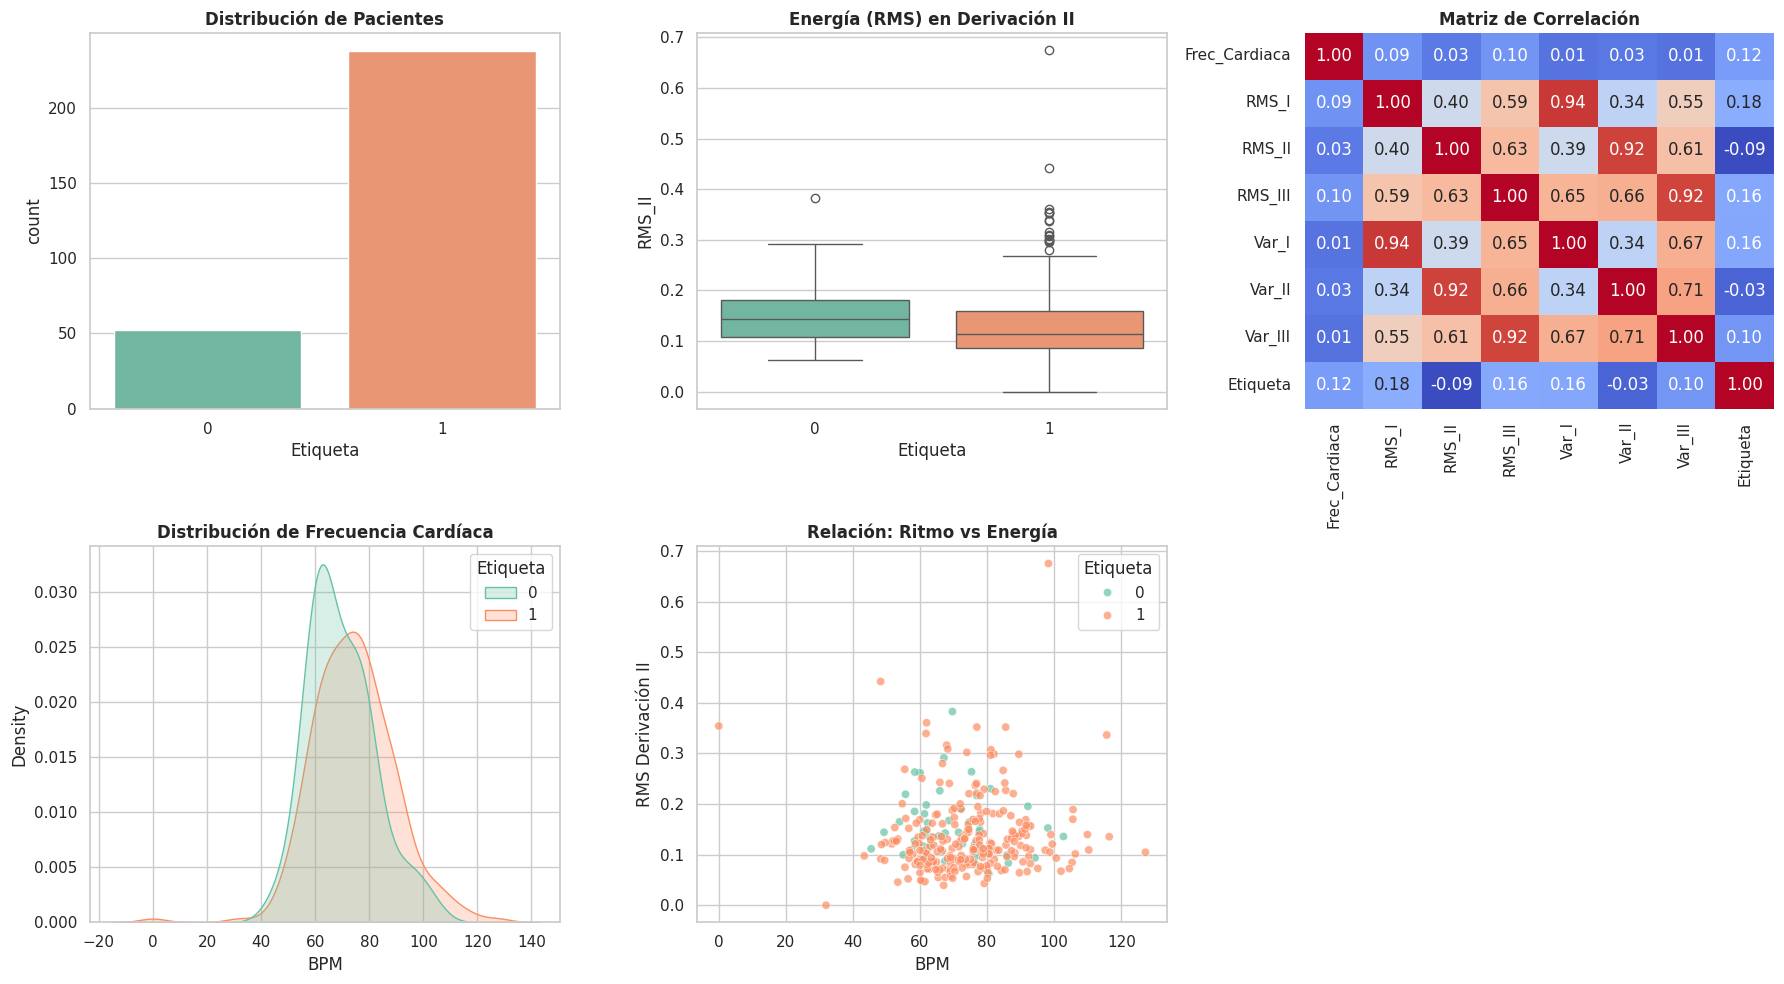

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
ruta_drive = '/content/drive/MyDrive/INTRODUCCION_A_SEÑALES/PROYECTO_SEÑALES/Datos_Clasificados'
ruta_csv = os.path.join(ruta_drive, 'Dataset_ECG.csv')
df = pd.read_csv(ruta_csv)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 10))
#Diagrama de barras
plt.subplot(2, 3, 1)
sns.countplot(data=df, x='Etiqueta', hue='Etiqueta', palette='Set2', legend=False)
plt.title('Distribución de Pacientes', fontweight='bold')
#Diagrama de cajas y bigotes:
plt.subplot(2, 3, 2)
sns.boxplot(data=df, x='Etiqueta', y='RMS_II', hue='Etiqueta', palette='Set2', legend=False)
plt.title('Energía (RMS) en Derivación II', fontweight='bold')
#Matriz de correlación:
plt.subplot(2, 3, 3)
columnas_numericas = df.drop(columns=['ID_Paciente'])
sns.heatmap(columnas_numericas.corr(), annot=True, cmap='coolwarm', fmt=".2f", cbar=False)
plt.title('Matriz de Correlación', fontweight='bold')
#Distribución:
plt.subplot(2,3,4)
sns.kdeplot(data=df, x='Frec_Cardiaca', hue='Etiqueta', fill=True, palette='Set2', common_norm=False)
plt.title('Distribución de Frecuencia Cardíaca', fontweight='bold')
plt.xlabel('BPM')
#Diagrama de dispersión:
plt.subplot(2, 3, 5)
sns.scatterplot(data=df, x='Frec_Cardiaca', y='RMS_II', hue='Etiqueta', palette='Set2', alpha=0.7)
plt.title('Relación: Ritmo vs Energía', fontweight='bold')
plt.xlabel('BPM')
plt.ylabel('RMS Derivación II')

# Dejamos el espacio 6 vacío para mantener la estética centrada, o lo ajustamos con tight_layout
plt.tight_layout()
plt.show()

## **Distribución de Pacientes:**
Se observa una barra verde pequeña para la clase 0 (Sanos) y una barra naranja gigante para la clase 1 (Patológicos). Se tiene un desbalance masivo de 50 sanos con casi 240 enfermos.

## **Energía (RMS) en Derivación II:**
Se observa una mayor cantidad de círculos arriba de la caja naranja, estos vienen a ser los outsiders (valores atípicos), esto se debe a que los corazones sanos mantienen una energía eléctrica estable y contenida mientras que los patológicos como los bloqueos de rama o las hipertrofias, pueden generar voltajes erráticos, altísimos o bajísimos .


## **Matriz Correlación:**
Cada uno con su respectiva derivada, dispersio de la señal. Debido al filtro pasabanda, que acerca la media a cero, el MRD y varinza son casi identicos, ambos miden dispersion de amplitud

## **Distribución de Frecuenca Cardíaca:**
Probabilidad de encontrar pacientes segun la frecuencia cardiaca.
La curva verde, que representa a los pacientes sanos, tiene un pico muy marcado y estrecho alrededor de los 60 a 65 BPM
los pacientes patológicos no solo tiene su pico desplazado hacia la derecha (cerca de los 75-80 BPM), sino que es mucho más ancha.
## **Relación: Ritmo vs Energía:**
Sobreposicion de patologias sobre pacientes sanos, baja separabilidad lineal
se observa un gran desbalance de datos, los puntos naranzjas envuelven a lso verdes

#Aplicación del Random Forest: ***Creación de un SMOTE***

In [ ]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
#Dataset:
ruta_drive = '/content/drive/MyDrive/INTRODUCCION_A_SEÑALES/PROYECTO_SEÑALES/Datos_Clasificados'
ruta_csv = os.path.join(ruta_drive,'Dataset_ECG.csv')
df = pd.read_csv(ruta_csv)
X = df.drop(columns=['ID_Paciente', 'Etiqueta'])
y = df['Etiqueta']
#Dividimos los datos en train y test denuevo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=1, stratify=y)
print(y_train.value_counts())
#Normalizar:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
#Aplicamos smote al train:
smote = SMOTE(random_state=1)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
print(y_train_smote.value_counts())
#Ahora si aplicamos random forest otra vez:
modelo_final = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=1)
modelo_final.fit(X_train_smote, y_train_smote)
#Evaluamos:
predicciones = modelo_final.predict(X_test_scaled)
exactitud = accuracy_score(y_test, predicciones)
print(f"RENDIMIENTO DEL SISTEMA: {exactitud * 100:.2f}% de Exactitud\n")
print("\nReporte Clínico:")
print(classification_report(y_test, predicciones, target_names=['Sano (0)', 'Patológico (1)']))

# Matriz de confusión
matriz = confusion_matrix(y_test, predicciones)
print("Matriz de Confusión:")
print(f"   [Sanos Reales detectados bien: {matriz[0,0]}]   [Falsos Patológicos (Error): {matriz[0,1]}]")
print(f"   [Falsos Sanos (Error): {matriz[1,0]}]        [Patológicos detectados bien: {matriz[1,1]}]")

Etiqueta
1    190
0     42
Name: count, dtype: int64
Etiqueta
1    190
0    190
Name: count, dtype: int64

RENDIMIENTO DEL SISTEMA: 77.59% de Exactitud

Reporte Clínico:
                precision    recall  f1-score   support

      Sano (0)       0.33      0.30      0.32        10
Patológico (1)       0.86      0.88      0.87        48

      accuracy                           0.78        58
     macro avg       0.60      0.59      0.59        58
  weighted avg       0.77      0.78      0.77        58

Matriz de Confusión:
   [Sanos Reales detectados bien: 3]   [Falsos Patológicos (Error): 7]
   [Falsos Sanos (Error): 6]        [Patológicos detectados bien: 42]
